# Portfolio risk review

A financier's weekly review of a CargoFlow book, from the public read API only: what is committed, drawn and
sitting in escrow, how the evidence pipeline has behaved (pauses, recoveries, release latency), and a Monte Carlo
of default and recovery driven by the historical epoch outcomes.

Run it as a notebook (`jupyter nbconvert --to notebook --execute portfolio_risk_review.ipynb`) or as a script
(`python portfolio_risk_review.py`). Set `CARGOFLOW_API_URL` to point at another deployment.

In [1]:
import os

import pandas as pd

from cargoflow import CargoFlow
from cargoflow import analytics as cfa

try:  # rich tables in Jupyter, plain text when run as a script
    from IPython.display import display as show
except ImportError:
    show = print

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

API = os.environ.get("CARGOFLOW_API_URL", "https://cargoflow-api-75ul.onrender.com")
cf = CargoFlow(API, timeout=90, retries=4, backoff=2)
print(cf.health())
print(cf.stats())

status='ok' chain_id=46630 database='ok' head_block=128101910


shipments={'ACTIVE': 2, 'PAUSED': 1, 'SETTLED': 1} total=4 epochs_committed=9 proofs_verified=1


## The book
`portfolio()` fetches every shipment's view, epochs and per-epoch track concurrently.

In [2]:
pf = cf.portfolio()
ships = pf.shipments_frame()
show(ships[["external_ref", "status", "route", "cargo", "invoice_value", "committed", "drawn", "in_escrow", "milestones_released", "milestones", "latest_score"]])

,external_ref,status,route,cargo,invoice_value,committed,drawn,in_escrow,milestones_released,milestones,latest_score
0,CF-MEERA-0411,ACTIVE,"18.9,73.0 -> 1.3,103.8",2 to 8°C,30.00,20.00,8.00,12.00,2,5,100.00
1,CF-MEERA-0410,ACTIVE,"18.9,73.0 -> 1.3,103.8",2 to 8°C,2.00,1.00,0.00,1.00,0,5,NaN
2,CF-LIVE-1790936950736,SETTLED,"18.9,73.0 -> 1.3,103.8",2 to 8°C,30.00,20.00,20.00,0.00,5,5,100.00
3,CF-LIVE-1790936827464,PAUSED,"18.9,73.0 -> 1.3,103.8",2 to 8°C,30.00,20.00,0.00,20.00,0,5,70.00


## Exposure
USDG. `in_escrow` is funded in the vault but not yet drawn on open facilities; `uncovered_drawn` is what the
financier would lose if every open facility defaulted and nothing were recovered beyond accepted cover.

In [3]:
show(cfa.exposure(pf))

,shipments,invoice_value,committed,drawn,in_escrow,undrawn,covered,uncovered_drawn,share_of_drawn
status,,,,,,,,,
ACTIVE,2,32.00,21.00,8.00,13.00,13.00,0.00,8.00,0.29
PAUSED,1,30.00,20.00,0.00,20.00,20.00,0.00,0.00,0.00
SETTLED,1,30.00,20.00,20.00,0.00,0.00,0.00,0.00,0.71
TOTAL,4,92.00,61.00,28.00,33.00,33.00,0.00,8.00,1.00


In [4]:
show(cfa.exposure(pf, by="cargo"))

,shipments,invoice_value,committed,drawn,in_escrow,undrawn,covered,uncovered_drawn,share_of_drawn
cargo,,,,,,,,,
2 to 8°C,4,92.00,61.00,28.00,33.00,33.00,0.00,8.00,1.00
TOTAL,4,92.00,61.00,28.00,33.00,33.00,0.00,8.00,1.00


## Counterparties
Each exporter's track record across the platform (`GET /v1/parties/{address}`).

In [5]:
rows = []
for addr in sorted(set(ships["exporter"])):
    p = cf.party(addr)
    rows.append({"exporter": addr, "grade": p.grade, "shipments": p.exporter.shipments, "settled": p.exporter.settled, "paused": p.exporter.paused, "defaulted": p.exporter.defaulted, "recoveries": p.exporter.recoveries, "avg_evidence_score": p.exporter.avg_evidence_score, "volume_usdg": p.exporter.volume / 1e6})
show(pd.DataFrame(rows))

,exporter,grade,shipments,settled,paused,defaulted,recoveries,avg_evidence_score,volume_usdg
0,0x8e6877a28d51a6c2b1699154cc17f3ebf682102f,A,2,1,1,0,1,82.20,60.00
1,0xa6c05ec62a222b0fb65bd30b2d2f9b2fd378911b,new,2,0,0,0,0,91.30,32.00


## Evidence pipeline behaviour
Pauses and their outcomes (open pauses are censored, not counted as failures) and the time from the approving
evidence epoch to the milestone release on chain.

In [6]:
show(cfa.recovery_rates(pf))

,pauses,recovered,defaulted,open,recovery_rate,with_proof,mean_time_to_recovery_s
shipment_id,,,,,,,
0x5a9082d1854c1cc3e5fcf8aa1ebc3a3560495e03ee7d00110baf256fe9b49d61,1,1,0,0,1.00,1,37.05
0xded44ff67a4e2e2f266097873494c2fbbc9326daf6a2b98ccda63dce8b1cb403,1,0,0,1,NaN,0,NaN
TOTAL,2,1,0,1,1.00,1,37.05


In [7]:
lat = cfa.release_latency(pf)
show(lat["latency_s"].describe())

count   7.00
mean    3.63
std     1.63
min     2.27
25%     2.60
50%     3.32
75%     3.79
max     7.05
Name: latency_s, dtype: float64

## Monte Carlo of default and recovery
The two driving probabilities come from history: a milestone evaluation pauses the facility with `p_pause`, a
pause is recovered with `p_recover`. Each simulation draws both from their Beta posteriors (so a short history
widens the distribution), walks every open facility through its remaining milestones, and books
`EAD - cover - salvage` on default. See `cfa.simulate_default_recovery` for the full model.

In [8]:
rates = cfa.estimate_epoch_rates(pf)
print(f"evaluations={rates.evaluations} pauses={rates.pauses} recovered={rates.recovered} defaulted={rates.defaulted}")
print(f"p_pause ~ Beta({rates.pause_alpha:g}, {rates.pause_beta:g}), mean {rates.pause_mean:.1%}")
print(f"p_recover ~ Beta({rates.recover_alpha:g}, {rates.recover_beta:g}), mean {rates.recover_mean:.1%}")

mc = cfa.simulate_default_recovery(pf, n_sims=20_000, seed=2026)
show(pd.Series(mc.summary()))

evaluations=9 pauses=2 recovered=1 defaulted=0
p_pause ~ Beta(3, 8), mean 27.3%
p_recover ~ Beta(2, 1), mean 66.7%


shipments                3.00
simulations         20,000.00
exposure_now             8.00
expected_defaults        1.08
prob_any_default         0.65
expected_loss            2.93
loss_std                 4.76
var_95                  13.14
var_99                  18.23
es_95                   16.16
es_99                   21.28
pause_prob_mean          0.27
recover_prob_mean        0.67
dtype: float64

In [9]:
show(mc.by_shipment().merge(ships[["shipment_id", "external_ref", "status"]], on="shipment_id"))

,shipment_id,exposure_now,default_probability,ead_given_default,expected_loss,loss_p99,external_ref,status
0,0xbaee21438df729eaed5dc040ca1f99b934f556a15497...,8.00,0.23,11.52,1.92,14.10,CF-MEERA-0411,ACTIVE
1,0xded44ff67a4e2e2f266097873494c2fbbc9326daf6a2...,0.00,0.51,2.56,0.93,13.02,CF-LIVE-1790936827464,PAUSED
2,0xe379a88c0363e2fa3a2c0535c572f6c8ec34a6b06106...,0.00,0.34,0.34,0.08,0.69,CF-MEERA-0410,ACTIVE


### Sensitivity
How the tail moves with the salvage assumption and with a more sceptical prior on recoveries.

In [10]:
scenarios = {
    "base (salvage Beta(2,5))": dict(),
    "no salvage": dict(salvage=0.0),
    "salvage 60%": dict(salvage=0.6),
    "sceptical prior Beta(1,3)": dict(prior=(1.0, 3.0)),
    "posterior means only": dict(parameter_uncertainty=False),
}
sens = pd.DataFrame({name: cfa.simulate_default_recovery(pf, n_sims=20_000, seed=2026, **kw).summary() for name, kw in scenarios.items()}).T
show(sens[["prob_any_default", "expected_loss", "var_95", "var_99", "es_99"]])

,prob_any_default,expected_loss,var_95,var_99,es_99
"base (salvage Beta(2,5))",0.65,2.93,13.14,18.23,21.28
no salvage,0.65,4.10,16.20,24.20,28.00
salvage 60%,0.65,1.64,6.48,9.68,11.20
"sceptical prior Beta(1,3)",0.88,3.78,13.49,18.60,21.60
posterior means only,0.81,3.49,13.63,19.12,22.03


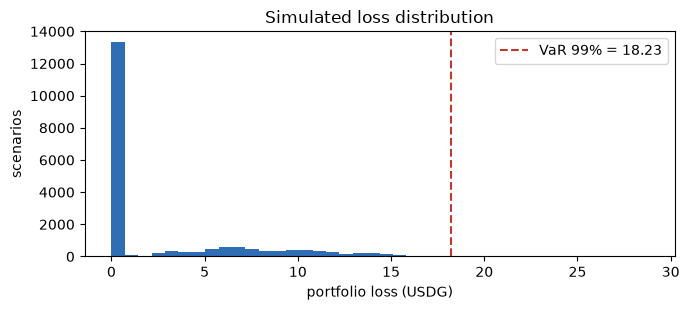

In [11]:
try:
    import matplotlib

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(mc.portfolio_losses, bins=40, color="#2f6db5")
    ax.axvline(mc.var(0.99), color="#c0392b", linestyle="--", label=f"VaR 99% = {mc.var(0.99):,.2f}")
    ax.set_xlabel("portfolio loss (USDG)")
    ax.set_ylabel("scenarios")
    ax.set_title("Simulated loss distribution")
    ax.legend()
    fig.tight_layout()
    os.makedirs("output", exist_ok=True)
    fig.savefig(os.path.join("output", "loss_distribution.png"), dpi=120)
    show(fig)
    plt.close(fig)
except ImportError:
    print("matplotlib not installed; skipping the chart")